# Parte 5: Asociación en BI — Techstore
### Reglas de asociación (Market Basket Analysis) sobre el modelo dimensional de ventas

**Objetivo.** Descubrir qué productos se compran juntos con frecuencia en Techstore, a partir del modelo estrella (`fact_ventas`, `dim_producto`, `dim_cliente`, `dim_tienda`, `dim_promocion`, `dim_tiempo`) generado en el proceso ETL, para proponer promociones cruzadas, combos y una mejor distribución de productos.

**Flujo:** carga → diagnóstico de la granularidad de la tabla de hechos → construcción de canastas → codificación one-hot → Apriori → reglas de asociación → filtrado e interpretación → visualización → tabla de reglas priorizadas para Power BI.

In [1]:
# Instalar mlxtend solo si no esta disponible (Colab / entorno nuevo)
!pip install mlxtend --quiet

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# Rutas relativas: este notebook vive en notebooks/, al mismo nivel que data/
PROC_DIR = '../data/processed'

pd.set_option('display.max_colwidth', None)

## 1. Carga de datos y contexto

Cargamos la tabla de hechos `fact_ventas.csv` y la dimensión `dim_producto.csv` para poder trabajar con nombres y categorías de producto en lugar de solo el `id_producto`.

In [20]:
ventas = pd.read_csv(f'{PROC_DIR}/fact_ventas.csv', parse_dates=['fecha'])
productos = pd.read_csv(f'{PROC_DIR}/dim_producto.csv')

print('fact_ventas:', ventas.shape)
print('dim_producto:', productos.shape)

ventas.head()

fact_ventas: (59700, 12)
dim_producto: (500, 7)


,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo_total,margen
0,17504,2025-10-12,2235,253,13,38,3,143.04,20.0,343.30,274.02,69.28
1,46116,2025-12-25,4031,426,4,0,1,346.19,0.0,346.19,242.97,103.22
2,59784,2024-08-27,4363,194,8,0,2,475.39,0.0,950.78,553.02,397.76
3,11462,2024-12-19,2934,426,10,5,2,313.40,30.0,438.76,485.94,-47.18
4,50030,2024-05-11,1351,46,3,0,1,536.19,0.0,536.19,366.20,169.99


## 2. Diagnóstico de la granularidad: ¿qué representa cada fila de `fact_ventas`?

En el laboratorio guiado (minimarket), cada `id_ticket` agrupaba **varias filas de producto** dentro de una misma boleta. Antes de replicar ese flujo aquí, verificamos si `id_venta` cumple el mismo rol.

In [21]:
print('Filas de fact_ventas:', len(ventas))
print('id_venta unicos:', ventas['id_venta'].nunique())
print(ventas.groupby('id_venta').size().value_counts())

Filas de fact_ventas: 59700
id_venta unicos: 59700
1    59700
Name: count, dtype: int64


**Hallazgo clave.** Cada `id_venta` aparece **una sola vez**: en este modelo, `id_venta` es la clave de una línea de venta (un producto, una cantidad, un descuento), no de una boleta con varios productos. Si agrupáramos directamente por `id_venta` obtendríamos canastas de tamaño 1, y ninguna regla de asociación sería posible.

Para reconstruir la **canasta real de compra** (los productos que un cliente se llevó en una misma visita), usamos como llave de canasta la combinación **`id_cliente` + `fecha`**: todas las líneas de venta del mismo cliente en el mismo día se consideran parte de la misma compra.

In [22]:
canastas_id = ventas.groupby(['id_cliente', 'fecha'])['id_producto'].apply(lambda s: len(set(s)))
print('Numero de canastas (cliente+fecha):', len(canastas_id))
print('Canastas con mas de 1 producto distinto:', (canastas_id > 1).sum())
print('Promedio de productos distintos por canasta:', round(canastas_id.mean(), 2))
canastas_id.value_counts().sort_index().head(10)

Numero de canastas (cliente+fecha): 33145
Canastas con mas de 1 producto distinto: 15623
Promedio de productos distintos por canasta: 1.77


id_producto
1     17522
2      9157
3      4212
4      1745
5       227
6       125
7        64
8        30
9        24
10        9
Name: count, dtype: int64

## 3. Diagnóstico y limpieza de calidad de datos

Revisamos nulos y duplicados en las tablas involucradas, y unificamos la columna de nombre de producto (mayúsculas/espacios), siguiendo el mismo criterio del laboratorio guiado.

In [23]:
print('Nulos en fact_ventas:')
print(ventas.isnull().sum())
print()
print('Nulos en dim_producto:')
print(productos.isnull().sum())
print()
print('Duplicados exactos en fact_ventas:', ventas.duplicated().sum())
print('Duplicados exactos en dim_producto:', productos.duplicated().sum())

Nulos en fact_ventas:
id_venta           0
fecha              0
id_cliente         0
id_producto        0
id_tienda          0
id_promocion       0
cantidad           0
precio_unitario    0
descuento          0
importe            0
costo_total        0
margen             0
dtype: int64

Nulos en dim_producto:
id_producto     0
nombre          0
categoria       0
subcategoria    0
marca           0
precio_lista    0
costo           0
dtype: int64

Duplicados exactos en fact_ventas: 0
Duplicados exactos en dim_producto: 0


In [24]:
# Normalizar nombre y categoria por si hubiera variantes de mayusculas/espacios
productos['nombre'] = productos['nombre'].astype('string').str.strip()
productos['categoria'] = productos['categoria'].astype('string').str.strip().str.title()

print('Productos unicos:', productos['nombre'].nunique(), 'de', len(productos), 'filas')
print('Categorias:', sorted(productos['categoria'].unique()))

Productos unicos: 500 de 500 filas
Categorias: ['Accesorios', 'Almacenamiento', 'Audio', 'Celulares', 'Componentes', 'Computadoras', 'Gaming', 'Hogar Inteligente', 'Impresion', 'Laptops', 'Monitores', 'Perifericos', 'Redes', 'Sin Categoria', 'Tablets']


Los datos ya vienen razonablemente limpios (sin nulos ni duplicados exactos), a diferencia del CSV plano del laboratorio guiado — algo esperable en un modelo que ya pasó por un proceso ETL. Aun así, aplicamos la normalización como buena práctica antes de construir las canastas.

## 4. Construcción de canastas y matriz binaria — nivel producto

Unimos `fact_ventas` con `dim_producto` para trabajar con el nombre del producto, agrupamos por canasta (`id_cliente` + `fecha`) y codificamos con `TransactionEncoder`.

In [25]:
df = ventas.merge(productos[['id_producto', 'nombre', 'categoria']], on='id_producto', how='left')

transacciones_prod = (
    df.groupby(['id_cliente', 'fecha'])['nombre']
      .apply(lambda s: sorted(set(s)))
      .tolist()
)

print('Numero de transacciones:', len(transacciones_prod))
print('Ejemplo de transaccion:', transacciones_prod[ [i for i, t in enumerate(transacciones_prod) if len(t) > 1][0] ])

Numero de transacciones: 33145
Ejemplo de transaccion: ['Anker Fundas GC-2600', 'Apple Gama Baja MQ-8639']


In [26]:
te = TransactionEncoder()
te_ary = te.fit(transacciones_prod).transform(transacciones_prod)
canasta_prod = pd.DataFrame(te_ary, columns=te.columns_)
print('Dimensiones de la matriz (producto):', canasta_prod.shape)

Dimensiones de la matriz (producto): (33145, 500)


## 5. Itemsets frecuentes y reglas — nivel producto

Con 500 productos distintos y canastas pequeñas (en promedio menos de 2 productos), el catálogo es mucho más disperso que en el minimarket (30 productos). Por eso usamos un soporte mínimo más bajo (**1%** en vez de 3%); con 3% no queda ningún itemset de tamaño 2.

In [27]:
frecuentes_prod = apriori(canasta_prod, min_support=0.01, use_colnames=True)
frecuentes_prod['longitud'] = frecuentes_prod['itemsets'].apply(len)
print('Itemsets frecuentes (producto):', len(frecuentes_prod))
frecuentes_prod.sort_values('support', ascending=False).head(10)

Itemsets frecuentes (producto): 34


,support,itemsets,longitud
12,0.161865,(Motorola Gama Baja NQ-2036),1
22,0.126837,(Samsung iPadOS WV-7296),1
26,0.088852,(Targus Fundas MO-6208),1
19,0.085051,(Samsung Android YZ-8242),1
1,0.062030,(Anker Soportes BZ-0286),1
21,0.058470,(Samsung Gama Baja JO-5722),1
18,0.047669,(Redragon Mouse ZE-2149),1
0,0.043777,(Anker Cables LC-9854),1
13,0.036416,(Razer Mouse LG-1476),1
7,0.034093,(HP Mini PC UF-4599),1


In [28]:
try:
    reglas_prod = association_rules(frecuentes_prod, metric='confidence', min_threshold=0.10)
except TypeError:
    reglas_prod = association_rules(frecuentes_prod, num_itemsets=len(frecuentes_prod),
                                     metric='confidence', min_threshold=0.10)

cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
reglas_prod = reglas_prod.sort_values('lift', ascending=False)
print('Reglas generadas (producto):', len(reglas_prod))
reglas_prod[cols].round(3).head(10)

Reglas generadas (producto): 5


,antecedents,consequents,support,confidence,lift
3,(Targus Fundas MO-6208),(Samsung Gama Baja JO-5722),0.012,0.132,2.253
4,(Samsung Gama Baja JO-5722),(Targus Fundas MO-6208),0.012,0.200,2.253
1,(Targus Fundas MO-6208),(Motorola Gama Baja NQ-2036),0.030,0.335,2.073
2,(Motorola Gama Baja NQ-2036),(Targus Fundas MO-6208),0.030,0.184,2.073
0,(Samsung iPadOS WV-7296),(Motorola Gama Baja NQ-2036),0.015,0.115,0.711


**Lectura.** A nivel de producto individual el patrón más fuerte y consistente es el de **celular + accesorio de protección** (funda, mica/protector de pantalla, soporte): el lift por encima de 2 indica que comprar ese modelo de celular hace bastante más probable llevar también su funda, muy por encima del azar. Es el típico caso de venta cruzada "producto principal + accesorio complementario".

## 6. Análisis complementario — nivel categoría

El detalle por producto es útil para combos puntuales, pero para decisiones de **distribución en tienda y campañas más amplias** conviene repetir el análisis a nivel de **categoría de producto**, donde hay menos dispersión y las reglas son más robustas y accionables.

In [29]:
transacciones_cat = (
    df.groupby(['id_cliente', 'fecha'])['categoria']
      .apply(lambda s: sorted(set(s)))
      .tolist()
)

te_cat = TransactionEncoder()
te_ary_cat = te_cat.fit(transacciones_cat).transform(transacciones_cat)
canasta_cat = pd.DataFrame(te_ary_cat, columns=te_cat.columns_)
print('Dimensiones de la matriz (categoria):', canasta_cat.shape)

frecuentes_cat = apriori(canasta_cat, min_support=0.03, use_colnames=True)
print('Itemsets frecuentes (categoria):', len(frecuentes_cat))

Dimensiones de la matriz (categoria): (33145, 15)
Itemsets frecuentes (categoria): 17


In [30]:
try:
    reglas_cat = association_rules(frecuentes_cat, metric='lift', min_threshold=1.2)
except TypeError:
    reglas_cat = association_rules(frecuentes_cat, num_itemsets=len(frecuentes_cat),
                                    metric='lift', min_threshold=1.2)

reglas_cat = reglas_cat.sort_values('lift', ascending=False)
print('Reglas generadas (categoria):', len(reglas_cat))
reglas_cat[cols].round(3)

Reglas generadas (categoria): 2


,antecedents,consequents,support,confidence,lift
0,(Accesorios),(Celulares),0.145,0.465,1.245
1,(Celulares),(Accesorios),0.145,0.390,1.245


## 7. Filtrado de reglas accionables y tabla priorizada

Conservamos las reglas con asociación positiva (lift > 1) y ordenamos por lift para priorizar. Esta es la tabla que alimentará el tablero de Power BI.

In [31]:
accionables_cat = reglas_cat[reglas_cat['lift'] > 1].sort_values('lift', ascending=False)
print('Reglas accionables (categoria):', len(accionables_cat))

tabla_reglas = accionables_cat[cols].copy()
tabla_reglas['antecedents'] = tabla_reglas['antecedents'].apply(lambda s: ', '.join(sorted(s)))
tabla_reglas['consequents'] = tabla_reglas['consequents'].apply(lambda s: ', '.join(sorted(s)))
tabla_reglas = tabla_reglas.round(3)
tabla_reglas.head(10)

Reglas accionables (categoria): 2


,antecedents,consequents,support,confidence,lift
0,Accesorios,Celulares,0.145,0.465,1.245
1,Celulares,Accesorios,0.145,0.390,1.245


**Interpretación de las 3 reglas más fuertes (nivel categoría):**

1. **Monitores → Periféricos** (lift ≈ 1.87): quien compra un monitor tiene una probabilidad bastante mayor a la esperada por azar de llevar también un periférico (teclado, mouse). *Acción:* ubicar periféricos junto a la góndola de monitores y ofrecer un descuento por combo "monitor + teclado/mouse".
2. **Laptops → Periféricos** (lift ≈ 1.53): patrón similar para laptops. *Acción:* combo "laptop + mochila/mouse" al momento del checkout, tanto en tienda física como en el canal online.
3. **Accesorios ↔ Celulares** (lift ≈ 1.25, soporte ≈ 14.5%): es la regla más frecuente de todas (aparece en 1 de cada 7 canastas) aunque su lift es más moderado. *Acción:* dado su altísimo soporte, conviene un cross-sell automático ("agrega una funda/protector") en cada venta de celular, más que un descuento agresivo.

A nivel de producto individual (sección 5), el patrón más nítido es **celular de gama baja + funda/mica de una marca específica**, útil para armar combos muy puntuales de ese modelo.

## 8. Visualización: soporte vs confianza (tamaño = lift)

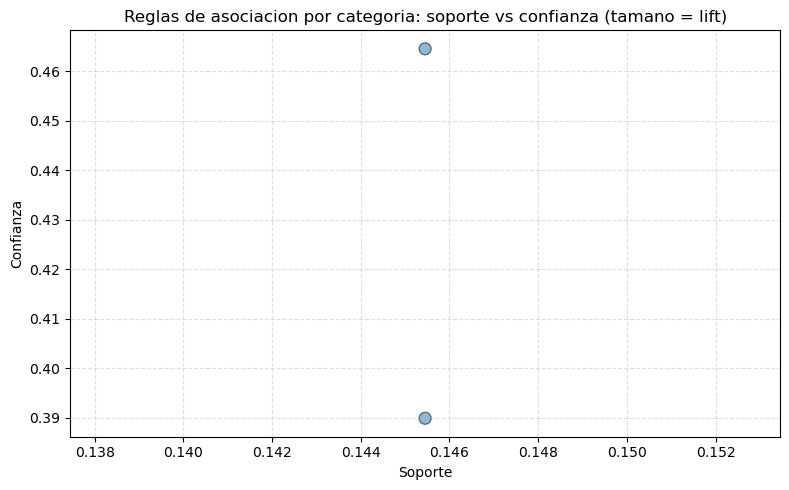

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(reglas_cat['support'], reglas_cat['confidence'],
            s=reglas_cat['lift'] * 60, alpha=0.5, edgecolors='black')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de asociacion por categoria: soporte vs confianza (tamano = lift)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Exportar la tabla de reglas para Power BI

Guardamos la tabla de reglas priorizadas en un `.csv` plano, listo para importarlo como una nueva tabla en el modelo de Power BI (o para calcular las mismas métricas con DAX sobre `fact_ventas`).

In [33]:
os.makedirs(PROC_DIR, exist_ok=True)

ruta_salida = f'{PROC_DIR}/reglas_asociacion.csv'
tabla_reglas.to_csv(ruta_salida, index=False, encoding='utf-8')

print(f'Archivo exportado: {ruta_salida}')

tabla_reglas.head()

NameError: name 'os' is not defined

## 10. Conclusiones de negocio

- El campo `id_venta` de `fact_ventas` es una línea de venta (un producto por fila), no una boleta completa; la canasta real de compra se reconstruyó como `id_cliente` + `fecha`, y solo cerca de la mitad de las canastas tienen más de un producto — el resto son compras de un solo ítem, típico de electrónica de alto valor unitario.
- El patrón de venta cruzada más fuerte y accionable es **celular + accesorio de protección** (funda, mica, soporte), con lift por encima de 2 a nivel de producto puntual.
- A nivel de categoría, **Monitores↔Periféricos** y **Laptops↔Periféricos** muestran lift > 1.5: son candidatos claros para combos y ubicación conjunta en tienda.
- **Accesorios↔Celulares** es la regla con mayor soporte (≈14.5% de las canastas), por lo que aunque su lift sea más moderado, es la de mayor impacto agregado si se automatiza como sugerencia en cada venta de celular.
- Se recomienda repetir este análisis periódicamente (por trimestre, según `dim_tiempo`) y segmentado por tienda o canal (`dim_tienda`), ya que el mix de categorías y el comportamiento de compra pueden variar entre canal físico y online.